# Whale species CNN — step by step

Same pipeline as `train.py`, split into cells so you can inspect every stage. Run top to bottom once, then poke at whatever you like.

Data: `../dataset/features/whales_32k_mel128_3s/` — 47,253 log-mel windows (128 mel × 301 frames, 3 s @ 32 kHz) with a leak-free
recording-group split in `manifest.csv`. Build it with `../dataset/scripts/extract_whale_features.py` if it's missing.

In [1]:
import json, time, pathlib, collections
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report, confusion_matrix

FEATURES = pathlib.Path("../dataset/features/whales_32k_mel128_3s")
RUN_DIR = pathlib.Path("runs/notebook"); RUN_DIR.mkdir(parents=True, exist_ok=True)
DEV = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print("device:", DEV)

device: mps


## 1. Load the tensors and the manifest

In [2]:
X = np.load(FEATURES / "windows.npy", mmap_mode="r")
X = np.ascontiguousarray(X)            # ~3.4 GB in RAM; comment out to keep it on disk (slower)
m = pd.read_csv(FEATURES / "manifest.csv")

# Species with too few tapes to evaluate fairly -> fold into other_whale (set to set() to keep all 24 classes)
RARE_TO_OTHER = {"Peponocephala_electra", "Stenella_clymene", "Stenella_frontalis", "Lagenodelphis_hosei"}
m.loc[m.label.isin(RARE_TO_OTHER), "label"] = "other_whale"
CLASSES = sorted(m.label.unique()); CID = {c: i for i, c in enumerate(CLASSES)}
m["y"] = m.label.map(CID)

print("windows:", X.shape, X.dtype, "| classes:", len(CLASSES))
m.groupby(["label", "split"]).size().unstack(fill_value=0)

windows: (47253, 128, 301) float16 | classes: 20


split,test,train,val
label,,,
Balaena_mysticetus,181,451,283
Balaenoptera_acutorostrata,1012,3977,1239
Balaenoptera_physalus,691,3219,689
Delphinapterus_leucas,28,113,28
Delphinus_delphis,201,622,321
Eubalaena_glacialis,1406,4655,1406
Globicephala_macrorhynchus,164,594,342
Globicephala_melas,245,1030,264
Grampus_griseus,75,221,124


## 2. Look at the data
Each row of `X` is one 3-second window. Rows are z-scored, so the color scale is in standard deviations.

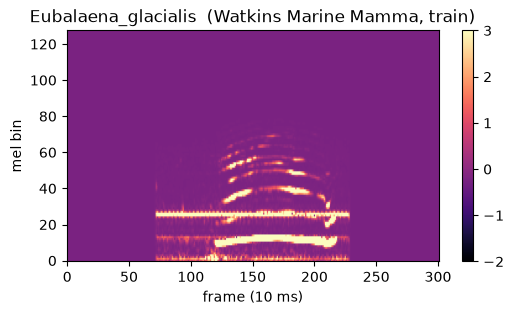

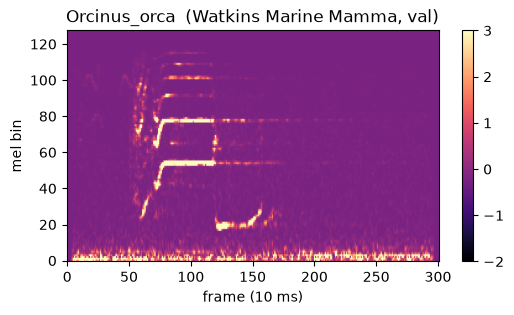

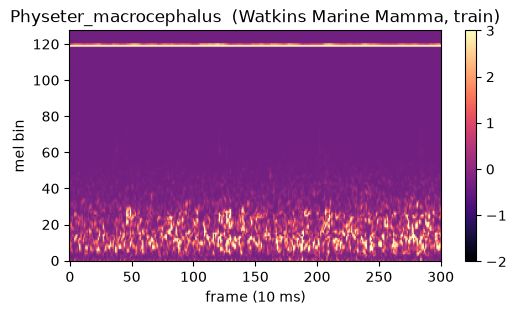

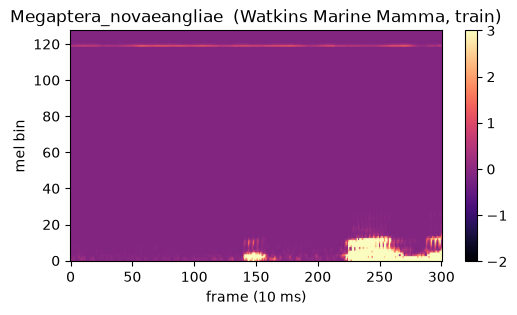

In [3]:
def show(idx, title=None):
    plt.figure(figsize=(6, 3)); plt.imshow(np.asarray(X[idx], dtype=np.float32), origin="lower", aspect="auto", cmap="magma", vmin=-2, vmax=3)
    r = m.iloc[idx]; plt.title(title or f"{r.label}  ({r.source[:20]}, {r.split})"); plt.xlabel("frame (10 ms)"); plt.ylabel("mel bin"); plt.colorbar(); plt.show()

for label in ["Eubalaena_glacialis", "Orcinus_orca", "Physeter_macrocephalus", "Megaptera_novaeangliae"]:
    show(m.index[m.label == label][0])

## 3. Dataset + augmentation
SpecAugment-lite: one frequency mask, one time mask, random gain. Toggle `augment=False` to see the effect on validation.

batch: torch.Size([128, 1, 128, 301]) torch.Size([128])


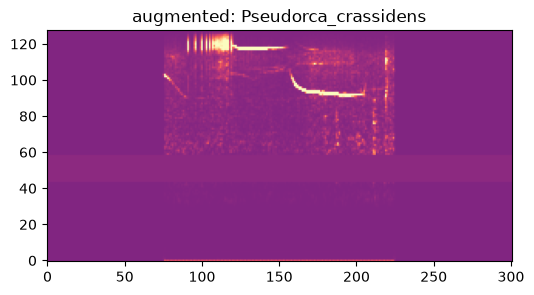

In [4]:
class WindowDataset(Dataset):
    def __init__(self, X, idx, y, augment=False): self.X, self.idx, self.y, self.augment = X, idx, y, augment
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        x = torch.from_numpy(np.asarray(self.X[self.idx[i]], dtype=np.float32))[None]   # (1, 128, 301)
        if self.augment:
            f0, fw = np.random.randint(0, 128 - 16), np.random.randint(0, 16); x[:, f0:f0 + fw, :] = 0
            t0, tw = np.random.randint(0, 301 - 30), np.random.randint(0, 30); x[:, :, t0:t0 + tw] = 0
            x = x * float(np.exp(np.random.uniform(-0.2, 0.2)))
        return x, self.y[i]

tr_idx = m.index[m.split == "train"].values; ytr = m.y.values[tr_idx]
counts = np.bincount(ytr, minlength=len(CLASSES)); w = 1.0 / np.sqrt(np.maximum(counts, 1))     # sqrt-inverse-frequency balancing

BATCH, STEPS_PER_EPOCH = 128, 250
sampler = WeightedRandomSampler(torch.as_tensor(w[ytr], dtype=torch.double), num_samples=STEPS_PER_EPOCH * BATCH, replacement=True)
train_dl = DataLoader(WindowDataset(X, tr_idx, ytr, augment=True), batch_size=BATCH, sampler=sampler, drop_last=True)

x, y = next(iter(train_dl)); print("batch:", x.shape, y.shape)
plt.figure(figsize=(6,3)); plt.imshow(x[0,0], origin="lower", aspect="auto", cmap="magma", vmin=-2, vmax=3); plt.title(f"augmented: {CLASSES[y[0]]}"); plt.show()

## 4. The model
4 conv blocks (32→64→128→256) → mean+max global pooling → dropout → linear. ~1.2 M parameters.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                                 nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True), nn.MaxPool2d(2))
    def forward(self, x): return self.net(x)

class WhaleCNN(nn.Module):
    def __init__(self, n_classes, width=32, dropout=0.3):
        super().__init__(); w = width
        self.features = nn.Sequential(ConvBlock(1, w), ConvBlock(w, 2*w), ConvBlock(2*w, 4*w), ConvBlock(4*w, 8*w))
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(8*w*2, n_classes))
    def forward(self, x):                                            # (B, 1, 128, 301)
        h = self.features(x)                                         # (B, 256, 8, 18)
        h = torch.cat([h.mean(dim=(2, 3)), h.amax(dim=(2, 3))], 1)   # (B, 512)
        return self.head(h)

model = WhaleCNN(len(CLASSES)).to(DEV)
print("params: %.2f M" % (sum(p.numel() for p in model.parameters()) / 1e6))
with torch.no_grad(): print("logits:", model(x[:4].to(DEV)).shape)

params: 1.18 M
logits: torch.Size([4, 20])


## 5. Evaluation helper
Reports window-level macro-F1 / accuracy and **clip-level** macro-F1 (majority vote over a clip's windows).

In [6]:
@torch.no_grad()
def predict_split(model, split, batch=256):
    model.eval(); idx = m.index[m.split == split].values
    dl = DataLoader(WindowDataset(X, idx, m.y.values[idx]), batch_size=batch, shuffle=False)
    p = torch.cat([model(xb.to(DEV)).argmax(1).cpu() for xb, _ in dl]).numpy()
    return idx, p, m.y.values[idx]

def evaluate(model, split):
    idx, p, y = predict_split(model, split)
    clip = pd.DataFrame({"clip": m.clip_id.values[idx], "p": p, "y": y}).groupby("clip").agg(p=("p", lambda s: s.mode().iloc[0]), y=("y", "first"))
    return {"macro_f1": f1_score(y, p, average="macro"), "acc": float((p == y).mean()), "clip_macro_f1": f1_score(clip.y, clip.p, average="macro")}, (idx, p, y)

print(evaluate(model, "val")[0])   # untrained baseline

{'macro_f1': 0.00921064929826201, 'acc': 0.014621466478934258, 'clip_macro_f1': 0.010854887837207687}


## 6. Train
Change `EPOCHS` freely; the loop keeps the best checkpoint by val macro-F1 in `runs/notebook/best.pt`. Re-run this cell to continue training the same model.

In [8]:
EPOCHS, LR = 12, 2e-3
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS * STEPS_PER_EPOCH)
history, best = [], -1
for ep in range(1, EPOCHS + 1):
    model.train(); t0 = time.time(); tot = n = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEV), yb.to(DEV)
        loss = F.cross_entropy(model(xb), yb, label_smoothing=0.05)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sched.step()
        tot += loss.item() * len(yb); n += len(yb)
    val, _ = evaluate(model, "val")
    history.append({"epoch": ep, "train_loss": tot / n, **val, "sec": time.time() - t0})
    print(f"epoch {ep:2d}  loss {tot/n:.3f}  val macro-F1 {val['macro_f1']:.3f}  acc {val['acc']:.3f}  clip-F1 {val['clip_macro_f1']:.3f}  ({time.time()-t0:.0f}s)")
    if val["macro_f1"] > best:
        best = val["macro_f1"]; torch.save({"model": model.state_dict(), "classes": CLASSES, "arch": {"width": 32}}, RUN_DIR / "best.pt")
h = pd.DataFrame(history); h[["train_loss", "macro_f1", "clip_macro_f1"]].plot(subplots=True, figsize=(6, 6)); plt.show()

## 7. Test-set results (best checkpoint)

In [ ]:
model.load_state_dict(torch.load(RUN_DIR / "best.pt", map_location=DEV)["model"])
test, (idx, p, y) = evaluate(model, "test"); print(test)
present = sorted(set(y) | set(p))
print(classification_report(y, p, labels=present, target_names=[CLASSES[i] for i in present], zero_division=0))

In [ ]:
cm = confusion_matrix(y, p, labels=list(range(len(CLASSES))), normalize="true")
plt.figure(figsize=(11, 9)); plt.imshow(cm, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(len(CLASSES)), CLASSES, rotation=90); plt.yticks(range(len(CLASSES)), CLASSES)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("test confusion (row-normalized)"); plt.colorbar(); plt.tight_layout(); plt.show()

## 8. Inspect mistakes
Pick a class and look at the windows it gets wrong.

In [ ]:
LOOK_AT = "Orcinus_orca"
wrong = [(i, pi) for i, pi, yi in zip(idx, p, y) if yi == CID[LOOK_AT] and pi != yi][:4]
for i, pi in wrong: show(i, title=f"true {LOOK_AT} -> predicted {CLASSES[pi]}")

## 9. Save a reload-able model
The checkpoint carries the class list, architecture, and the feature spec, so it can be reloaded without this notebook.

In [ ]:
feat_cfg = json.load(open(FEATURES / "labels.json"))["config"]
spec = {k: feat_cfg[k] for k in ("sr", "win_s", "n_fft", "hop", "n_mels", "fmin", "fmax")}
pathlib.Path("models").mkdir(exist_ok=True)
torch.save({"model": model.state_dict(), "classes": CLASSES, "arch": {"width": 32, "n_classes": len(CLASSES)}, "feature_spec": spec, "metrics": test},
           "models/whale_cnn_notebook.pt")
print("saved models/whale_cnn_notebook.pt")

# reload from scratch
ck = torch.load("models/whale_cnn_notebook.pt", map_location="cpu")
m2 = WhaleCNN(len(ck["classes"]), width=ck["arch"]["width"]); m2.load_state_dict(ck["model"]); m2.eval()
print("reloaded; classes:", len(ck["classes"]), "| test metrics:", ck["metrics"])

## 10. Predict on a raw WAV
Re-creates the exact feature pipeline (mono → 32 kHz → 3 s windows → log-mel → z-score). Try any file from `../dataset/audio/`.

In [ ]:
import soundfile as sf, librosa

def windows_from_wav(path, spec):
    y, sr0 = sf.read(str(path), dtype="float32", always_2d=True); y = y.mean(1); sr = int(spec["sr"])
    if sr0 != sr: y = librosa.resample(y, orig_sr=sr0, target_sr=sr, res_type="soxr_hq")
    n = int(spec["win_s"] * sr); hop = n // 2
    if len(y) < n: pad = n - len(y); y = np.pad(y, (pad // 2, pad - pad // 2)); starts = [0]
    else: starts = list(range(0, len(y) - n + 1, hop))
    T = 1 + n // int(spec["hop"]); out = np.zeros((len(starts), int(spec["n_mels"]), T), dtype=np.float32)
    for k, s in enumerate(starts):
        mel = librosa.feature.melspectrogram(y=y[s:s+n], sr=sr, n_fft=int(spec["n_fft"]), hop_length=int(spec["hop"]), n_mels=int(spec["n_mels"]), fmin=spec["fmin"], fmax=spec["fmax"])
        z = np.log1p(mel); z = (z - z.mean()) / (z.std() + 1e-6); out[k, :, :z.shape[1]] = z[:, :T]
    return out, [s / sr for s in starts]

def classify_wav(path, model=m2, top=3):
    W, offsets = windows_from_wav(path, spec)
    with torch.no_grad(): probs = torch.softmax(model(torch.from_numpy(W)[:, None]), 1).numpy()
    clip = probs.mean(0)
    for i in np.argsort(-clip)[:top]: print(f"  {ck['classes'][i]:32s} {clip[i]:.2f}")
    return probs, offsets

wav = pathlib.Path("../dataset/audio/orcasound/SRKW_call"); wav = next(wav.glob("*.wav")) if wav.exists() else None
if wav: print(wav.name); classify_wav(wav)
else: print("point `wav` at any .wav file")